In [ ]:
# 6D POSE ESTIMATION & DISTORTION-ABLATION TEST HARNESS
#
# PURPOSE:
#   Run YOLOv5-6D-Pose inference on validation images, estimate 6D object pose
#   via PnP, and compare reprojection error WITH vs WITHOUT lens distortion
#   correction to determine if distortion coefficients actually help.
#
# PIPELINE:
#   image → YOLOv5-6D → 9 keypoints (centroid + 8 bbox corners) in pixels
#     → solvePnP(3D model ↔ 2D corners) → rotation + translation → reprojection error
#
# DATA STRUCTURES:
#   corners_2d:       (9, 2) float — [centroid, corner1..corner8] in image pixels
#   object_points_3d: (9, 3) float — matching 3D points in object frame (meters)
#                     Default: Phantom 4 drone bounding box
#                       min/max extents ≈ 0.34 × 0.34 × 0.23 m
#   camera_matrix:    (3, 3) float — intrinsic K  [[fx,0,cx],[0,fy,cy],[0,0,1]]
#   dist_coeffs:      (5,)   float — [k1, k2, p1, p2, k3]  (OpenCV convention)
#   label format:     class  x0 y0  x1 y1 ... x8 y8  (normalized to unpadded image area)
#                     indices 1–18 = centroid + 8 corners, values in [0,1]
#
# DOES:
#   estimate_6d_pose():
#     - Takes 9 predicted 2D keypoints + camera intrinsics
#     - Runs cv2.solvePnP (ITERATIVE) on the 8 corners (drops centroid for stability)
#     - Returns rotation matrix, translation vector, and reprojection error
#
#   predict():
#     - Loads image + ground-truth label
#     - Letterbox-resizes, runs YOLOv5-6D inference
#     - Rescales predicted & GT corners back to original image space
#     - Returns pred/gt corners, confidence, mean corner error (pixels)
#
#   Main test loop:
#     - Loads model from phantom4/weights/best.pt
#     - Runs on ~300 validation images (skip first 30% = training split)
#     - For each image: estimates pose twice (with distortion, without)
#     - Compares mean/median/std reprojection error for both conditions
#     - Prints translation stats (X/Y/Z in meters) and recommendation
#
# INPUT DIRECTORY LAYOUT (EXPECTED):
#   DATA_DIR/
#     JPEGImages/*.jpg     — input images
#     labels/*.txt         — one label per image (class + 9×2 normalized coords + ...)
#
# CAMERA:
#   Phantom 4 intrinsics: fx≈fy≈1979, cx≈977, cy≈534
#   Distortion: k1=-0.23, k2=0.15, p1≈p2≈-0.001, k3=-0.05
#
# OUTPUT:
#   Console summary: reprojection error stats for both conditions,
#   translation distributions, and USE / DO NOT USE recommendation
#   based on mean error difference.
#
# DEPENDENCIES:
#   numpy, opencv, torch, tqdm
#   YOLOv5-6D-Pose repo (utils.datasets, utils.general, utils.pose_utils, models.experimental)
#
# NOTES:
#   - PnP uses only the 8 box corners (indices 1–8); centroid is excluded for stability.
#   - Reprojection error is mean L2 over the 8 corners (pixels).
#   - "Without distortion" means dist_coeffs = zeros, NOT undistorted images;
#     this tests whether PnP benefits from modeling lens distortion at solve time.

def estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs=None, object_points_3d=None):
    """
    Estimate 6D pose (rotation and translation) from 2D corner predictions using PnP.
    
    Args:
        corners_2d: Predicted 2D corners in image space (9x2 numpy array)
                   Format: [centroid, corner1, corner2, ..., corner8]
        camera_matrix: Camera intrinsic matrix (3x3 numpy array)
                      [[fx,  0, cx],
                       [ 0, fy, cy],
                       [ 0,  0,  1]]
        dist_coeffs: Distortion coefficients (5,) or (8,) numpy array (optional)
                    Format: [k1, k2, p1, p2, k3] or [k1, k2, p1, p2, k3, k4, k5, k6]
                    If None, assumes no distortion
        object_points_3d: 3D object points in object coordinate frame (9x3 numpy array)
                         Format: [centroid, corner1, corner2, ..., corner8]
                         If None, uses default Phantom 4 drone 3D model
    
    Returns:
        dict with keys:
            'success': Boolean indicating if pose estimation succeeded
            'rotation_matrix': 3x3 rotation matrix (camera frame ← object frame)
            'translation_vector': 3x1 translation vector (in meters)
            'rvec': 3x1 rotation vector (Rodrigues format)
            'tvec': 3x1 translation vector (same as translation_vector)
            'reprojection_error': Mean reprojection error in pixels
            
            If failed:
            'error_msg': Error message
    """
    
    # Default Phantom 4 3D model (in meters)
    if object_points_3d is None:
        # Bounding box dimensions
        min_x, max_x = -0.18, 0.16
        min_y, max_y = -0.16, 0.18
        min_z, max_z = -0.17, 0.06
        
        object_points_3d = np.array([
            [(min_x + max_x) / 2, (min_y + max_y) / 2, (min_z + max_z) / 2],  # centroid
            [min_x, min_y, min_z],  # corner 1
            [min_x, min_y, max_z],  # corner 2
            [min_x, max_y, min_z],  # corner 3
            [min_x, max_y, max_z],  # corner 4
            [max_x, min_y, min_z],  # corner 5
            [max_x, min_y, max_z],  # corner 6
            [max_x, max_y, min_z],  # corner 7
            [max_x, max_y, max_z],  # corner 8
        ], dtype=np.float32)
    
    # Default: no distortion
    if dist_coeffs is None:
        dist_coeffs = np.zeros(5, dtype=np.float32)
    
    # Validate inputs
    if corners_2d.shape[0] != 9 or corners_2d.shape[1] != 2:
        return {
            'success': False,
            'error_msg': f'corners_2d must be 9x2, got {corners_2d.shape}'
        }
    
    if object_points_3d.shape[0] != 9 or object_points_3d.shape[1] != 3:
        return {
            'success': False,
            'error_msg': f'object_points_3d must be 9x3, got {object_points_3d.shape}'
        }
    
    if camera_matrix.shape != (3, 3):
        return {
            'success': False,
            'error_msg': f'camera_matrix must be 3x3, got {camera_matrix.shape}'
        }
    
    try:
        # PnP expects: (N, 3) object points, (N, 2) image points
        # Skip centroid (index 0) - use only the 8 corners for more stable estimation
        obj_pts = object_points_3d[1:, :].astype(np.float32)  # 8x3
        img_pts = corners_2d[1:, :].astype(np.float32)  # 8x2
        
        # Solve PnP using ITERATIVE method (good for initial estimate)
        success, rvec, tvec = cv2.solvePnP(
            obj_pts, 
            img_pts, 
            camera_matrix, 
            dist_coeffs,
            flags=cv2.SOLVEPNP_ITERATIVE
        )
        
        if not success:
            return {
                'success': False,
                'error_msg': 'cv2.solvePnP returned failure'
            }
        
        # Convert rotation vector to rotation matrix
        rotation_matrix, _ = cv2.Rodrigues(rvec)
        
        # Compute reprojection error
        projected_pts, _ = cv2.projectPoints(
            obj_pts, 
            rvec, 
            tvec, 
            camera_matrix, 
            dist_coeffs
        )
        projected_pts = projected_pts.reshape(-1, 2)
        reprojection_error = np.mean(np.linalg.norm(projected_pts - img_pts, axis=1))
        
        return {
            'success': True,
            'rotation_matrix': rotation_matrix,
            'translation_vector': tvec.reshape(3, 1),
            'rvec': rvec,
            'tvec': tvec,
            'reprojection_error': reprojection_error
        }
        
    except Exception as e:
        return {
            'success': False,
            'error_msg': f'Exception during PnP: {str(e)}'
        }
    
def predict(model, image_path, label_path, img_size=640, conf_thresh=0.01, device='cpu'):
    """
    Get pose prediction for a single image.
    
    Args:
        model: Loaded YOLOv5-6D model
        image_path: Path to input image
        label_path: Path to label file (for ground truth)
        img_size: Input size for model (default: 640)
        conf_thresh: Confidence threshold for detections (default: 0.01)
        device: Device to run inference on ('cpu' or 'cuda')
    
    Returns:
        dict with keys:
            'pred_corners': Predicted corners in original image space (9x2 array)
            'gt_corners': Ground truth corners in original image space (9x2 array)
            'confidence': Prediction confidence score
            'error': Mean corner error in pixels (excluding centroid)
            'image': Original image (BGR format)
            'success': Boolean indicating if prediction was successful
    """
    from utils.datasets import letterbox
    from utils.general import check_img_size, scale_coords
    from utils.pose_utils import box_filter
    
    # Load image
    img0 = cv2.imread(str(image_path))
    if img0 is None:
        return {'success': False, 'error_msg': 'Failed to load image'}
    
    h0, w0 = img0.shape[:2]
    
    # Load label (expect 21+ values: class, centroid, 8 corners)
    try:
        with open(label_path) as f:
            label_data = [float(x) for x in f.readline().strip().split()]
        if len(label_data) < 21:
            return {'success': False, 'error_msg': f'Label has only {len(label_data)} values, need at least 21'}
    except Exception as e:
        return {'success': False, 'error_msg': f'Failed to load label: {e}'}
    
    # Prepare image for inference
    stride = int(model.stride.max())
    img_size = check_img_size(img_size, s=stride)
    
    # Letterbox resize
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # Convert to tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)  # BGR to RGB, HWC to CHW
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)  # Add batch dimension
    
    # Run inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    # Filter by confidence threshold
    pred = box_filter(pred, conf_thres=conf_thresh, max_det=10)
    
    if pred is None or len(pred) == 0 or len(pred[0]) == 0:
        return {'success': False, 'error_msg': 'No detections above confidence threshold'}

    # Get highest confidence detection
    det = pred[0][0].clone().cpu()
    confidence = float(det[18])
    corners_pred = det[:18].reshape(1, 18)
    
    # Scale predictions to original image space
    scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
    pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    
    # Process ground truth
    # Label format: [class, x0, y0, x1, y1, ..., x8, y8, ...]
    # Indices 1-18 contain centroid + 8 corners (normalized 0-1)
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Get letterbox dimensions
    _, _, height, width = img_tensor.shape
    
    # CRITICAL: Labels are normalized to unpadded image area
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    # Convert GT to letterbox pixels
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]  # x coords
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]  # y coords
    
    # Scale GT to original image space
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error (skip centroid at index 0)
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    return {
        'success': True,
        'pred_corners': pred_pixels,
        'gt_corners': gt_pixels,
        'confidence': confidence,
        'error': corner_error,
        'image': img0
    }
"""
Test script to determine if distortion correction is needed for PnP
"""

import numpy as np
import sys
from pathlib import Path
import cv2
import torch

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
# Load model
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/phantom4/weights/best.pt')
DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/Shiu/phantom4'

device = select_device('')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()



# Get test images
images_dir = DATA_DIR / 'JPEGImages'
labels_dir = DATA_DIR / 'labels'
image_files = sorted(list(images_dir.glob('*.jpg')))

# Test on 300 images from validation set (skip first 30% which is training)
start_idx = int(len(image_files) * 0.30)
end_idx = min(start_idx + 300, len(image_files))
test_images = image_files[start_idx:end_idx]

print(f"Testing on {len(test_images)} images from validation set...")

# Camera intrinsics
fx, fy, cx, cy = 1979.4, 1979.1, 976.8189, 533.9717
camera_matrix = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
], dtype=np.float32)

# Distortion coefficients
dist_coeffs = np.array([-0.2306, 0.1497, -0.00089582, -0.00086321, -0.0522086113480487], 
                      dtype=np.float32)

# Collect results
errors_with_dist = []
errors_without_dist = []
translations_with = []
translations_without = []
failed = 0

from tqdm import tqdm

for img_path in tqdm(test_images, desc="Testing"):
    label_path = labels_dir / f"{img_path.stem}.txt"
    
    result = predict(model, img_path, label_path, device=device)
    
    if not result['success']:
        failed += 1
        continue
    
    # Test with distortion
    pose_with = estimate_6d_pose(
        result['pred_corners'], 
        camera_matrix, 
        dist_coeffs=dist_coeffs
    )
    
    # Test without distortion
    pose_without = estimate_6d_pose(
        result['pred_corners'], 
        camera_matrix, 
        dist_coeffs=None
    )
    
    if pose_with['success']:
        errors_with_dist.append(pose_with['reprojection_error'])
        translations_with.append(pose_with['translation_vector'].flatten())
    
    if pose_without['success']:
        errors_without_dist.append(pose_without['reprojection_error'])
        translations_without.append(pose_without['translation_vector'].flatten())

# Convert to arrays
errors_with_dist = np.array(errors_with_dist)
errors_without_dist = np.array(errors_without_dist)
translations_with = np.array(translations_with)
translations_without = np.array(translations_without)

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"Tested: {len(test_images)} images")
print(f"Failed predictions: {failed}")
print(f"Successful: {len(errors_with_dist)}")

print("\n" + "-"*80)
print("WITH DISTORTION CORRECTION:")
print("-"*80)
print(f"Reprojection Error (pixels):")
print(f"  Mean:   {np.mean(errors_with_dist):.2f}")
print(f"  Median: {np.median(errors_with_dist):.2f}")
print(f"  Std:    {np.std(errors_with_dist):.2f}")
print(f"  Min:    {np.min(errors_with_dist):.2f}")
print(f"  Max:    {np.max(errors_with_dist):.2f}")

print(f"\nTranslation (meters):")
print(f"  X: {np.mean(translations_with[:, 0]):.3f} ± {np.std(translations_with[:, 0]):.3f}")
print(f"  Y: {np.mean(translations_with[:, 1]):.3f} ± {np.std(translations_with[:, 1]):.3f}")
print(f"  Z: {np.mean(translations_with[:, 2]):.3f} ± {np.std(translations_with[:, 2]):.3f}")

print("\n" + "-"*80)
print("WITHOUT DISTORTION CORRECTION:")
print("-"*80)
print(f"Reprojection Error (pixels):")
print(f"  Mean:   {np.mean(errors_without_dist):.2f}")
print(f"  Median: {np.median(errors_without_dist):.2f}")
print(f"  Std:    {np.std(errors_without_dist):.2f}")
print(f"  Min:    {np.min(errors_without_dist):.2f}")
print(f"  Max:    {np.max(errors_without_dist):.2f}")

print(f"\nTranslation (meters):")
print(f"  X: {np.mean(translations_without[:, 0]):.3f} ± {np.std(translations_without[:, 0]):.3f}")
print(f"  Y: {np.mean(translations_without[:, 1]):.3f} ± {np.std(translations_without[:, 1]):.3f}")
print(f"  Z: {np.mean(translations_without[:, 2]):.3f} ± {np.std(translations_without[:, 2]):.3f}")

print("\n" + "="*80)
print("RECOMMENDATION:")
print("="*80)
improvement = np.mean(errors_without_dist) - np.mean(errors_with_dist)
if improvement > 0:
    print(f"  → USE distortion correction")
    print(f"    Mean improvement: {improvement:.2f} pixels ({improvement/np.mean(errors_without_dist)*100:.1f}%)")
else:
    print(f"  → DO NOT use distortion correction")
    print(f"    Mean difference: {abs(improvement):.2f} pixels")
print("="*80)

/home/michal/git/YOLOv5-6D-Pose/utils/general.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/home/michal/anaconda3/envs/yolo6d/lib/python3.9/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Testing on 300 images from validation set...


Testing: 100%|██████████| 300/300 [04:08<00:00,  1.21it/s]


RESULTS SUMMARY
Tested: 300 images
Failed predictions: 0
Successful: 300

--------------------------------------------------------------------------------
WITH DISTORTION CORRECTION:
--------------------------------------------------------------------------------
Reprojection Error (pixels):
  Mean:   1.29
  Median: 0.83
  Std:    1.37
  Min:    0.37
  Max:    9.40

Translation (meters):
  X: -0.374 ± 0.607
  Y: -0.413 ± 0.108
  Z: 3.282 ± 0.583

--------------------------------------------------------------------------------
WITHOUT DISTORTION CORRECTION:
--------------------------------------------------------------------------------
Reprojection Error (pixels):
  Mean:   2.14
  Median: 1.94
  Std:    1.65
  Min:    0.43
  Max:    11.23

Translation (meters):
  X: -0.383 ± 0.621
  Y: -0.418 ± 0.109
  Z: 3.373 ± 0.612

RECOMMENDATION:
  → USE distortion correction
    Mean improvement: 0.85 pixels (39.6%)


In [ ]:
# YOLO6D SINGLE-FRAME PREDICTION vs GROUND-TRUTH VISUALIZER
#
# PURPOSE:
#   Run YOLOv5-6D-Pose inference on the first frame of the first sequence
#   in folder "02", overlay predicted and ground-truth 3D bounding box corners
#   on the image, and save/display the result for visual sanity-checking.
#
# PIPELINE:
#   image → letterbox resize → YOLOv5-6D inference → 9 keypoints (pixels)
#   label → parse normalized coords → undo letterbox → original image pixels
#   both sets of corners → draw 3D bbox wireframe edges → save PNG
#
# DATA STRUCTURES:
#   gt_norm:      (18,) float — centroid + 8 corners as x0,y0,x1,y1,...
#                 normalized to [0,1] relative to unpadded image area
#   pred_pixels:  (9, 2) float — [centroid, corner1..corner8] in original image pixels
#   gt_pixels:    (9, 2) float — same layout, from label
#   edges:        list of 12 [i,j] pairs — 3D bounding box wireframe topology
#                 indices are 0-based into the 8 corners (centroid excluded)
#   label format: class x0 y0 x1 y1 ... x8 y8 [extra...]
#                 indices 1–18 = centroid + 8 corners, normalized 0–1
#
# INPUT DIRECTORY LAYOUT (EXPECTED):
#   DATA_DIR/
#     JPEGImages/02/<seq_dir>/*.jpg   — image sequences
#     labels_yolo6d/02/<seq_dir>/*.txt — matching YOLO6D labels (same relative path)
#   WEIGHTS: phantom4/weights/best.pt
#
# DOES:
#   - Picks first sequence in JPEGImages/02/, first frame in that sequence
#   - Loads matching label from labels_yolo6d/ (mirror path, .txt extension)
#   - Runs YOLOv5-6D inference (conf_thresh=0.01), takes top detection
#   - Rescales both predicted and GT corners from letterbox space → original image
#   - Draws 12-edge wireframe for GT (green solid) and prediction (red dashed)
#   - Marks corners (GT=lime circles, pred=red crosses) and centroids (stars)
#   - Annotates title with filename, confidence, and mean corner error (pixels)
#   - Saves to first_frame_debug.png (150 dpi) and shows via plt.show()
#
# OUTPUT:
#   first_frame_debug.png — annotated overlay image
#   Console: image path, label path, letterbox params, confidence,
#            per-centroid coords + diff, mean corner error
#
# DEPENDENCIES:
#   numpy, opencv, torch, matplotlib
#   YOLOv5-6D-Pose repo (models.experimental, utils.{datasets,general,pose_utils,torch_utils})
#
# NOTES:
#   - Corner error is mean L2 over the 8 box corners (index 1–8); centroid excluded.
#   - Edge list uses 0-based corner indices; +1 offset applied when indexing into
#     the (9,2) arrays to skip the centroid at index 0.
#   - Letterbox undo: normalized coords × unpadded dims + pad offset → scale_coords.

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/data/phantom4'
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/phantom4/weights/best.pt')

# Find first sequence in folder 02
folder_02 = DATA_DIR / 'JPEGImages' / '02'
sequences = sorted([d for d in folder_02.iterdir() if d.is_dir()])
test_sequence = sequences[0]

# Get first image
image_files = sorted(test_sequence.glob('*.jpg'))
image_path = image_files[0]

print(f"Processing: {image_path.relative_to(DATA_DIR)}")

# Find corresponding YOLO label (GT corners)
rel_path = image_path.relative_to(DATA_DIR / 'JPEGImages')
yolo_label_path = DATA_DIR / 'labels_yolo6d' / rel_path.with_suffix('.txt')

print(f"YOLO label: {yolo_label_path.relative_to(DATA_DIR)}")
print(f"Exists: {yolo_label_path.exists()}")

if not yolo_label_path.exists():
    print("ERROR: YOLO label not found!")
    sys.exit(1)

# ============================================================================
# LOAD GT CORNERS FROM YOLO LABEL
# ============================================================================

with open(yolo_label_path) as f:
    label_data = [float(x) for x in f.readline().strip().split()]

print(f"\nLabel has {len(label_data)} values")
print(f"Label format: class + 9 keypoints (centroid + 8 corners), normalized 0-1")

# Extract GT corners (indices 1-18: centroid + 8 corners, normalized)
gt_norm = np.array([label_data[i] for i in range(1, 19)])

# ============================================================================
# LOAD IMAGE AND GET PREDICTION
# ============================================================================

# Load image
img0 = cv2.imread(str(image_path))
h0, w0 = img0.shape[:2]
print(f"\nImage size: {w0}x{h0}")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()

# Prepare image
stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
shape = (h0, w0)
shapes = ((h0, w0), (ratio, pad))

print(f"Letterbox: {img.shape[1]}x{img.shape[0]}, ratio={ratio}, pad={pad}")

# To tensor
img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
img_tensor = np.ascontiguousarray(img_tensor)
img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
if img_tensor.ndimension() == 3:
    img_tensor = img_tensor.unsqueeze(0)

# Inference
with torch.no_grad():
    pred, _ = model(img_tensor)

pred = box_filter(pred, conf_thres=0.01, max_det=10)

if pred is None or len(pred) == 0 or len(pred[0]) == 0:
    print("ERROR: No detections!")
    sys.exit(1)

det = pred[0][0].clone().cpu()
confidence = float(det[18])
corners_pred = det[:18].reshape(1, 18)

# Scale predictions to original image space
scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
pred_pixels = corners_pred[0].numpy().reshape(9, 2)

print(f"\n✓ Prediction successful (confidence: {confidence:.3f})")

# ============================================================================
# SCALE GT CORNERS TO ORIGINAL IMAGE SPACE
# ============================================================================

# Get letterbox dimensions
_, _, height, width = img_tensor.shape

# Labels are normalized to unpadded image area
unpadded_w = width - 2 * pad[0]
unpadded_h = height - 2 * pad[1]

# Scale by unpadded dimensions
gt_letterbox = gt_norm.copy()
gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w  # x coords
gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h  # y coords

# Add padding offset
gt_letterbox[::2] += pad[0]  # x offset
gt_letterbox[1::2] += pad[1]  # y offset

# Scale to original image space
gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])

gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)

# ============================================================================
# VISUALIZE
# ============================================================================

# 3D bounding box edges
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Show image
img_rgb = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
ax.imshow(img_rgb)

# Draw GT (green)
for i, edge in enumerate(edges):
    ax.plot([gt_pixels[edge[0]+1, 0], gt_pixels[edge[1]+1, 0]], 
            [gt_pixels[edge[0]+1, 1], gt_pixels[edge[1]+1, 1]], 
            'g-', linewidth=3, label='Ground Truth' if i==0 else '')
ax.scatter(gt_pixels[1:, 0], gt_pixels[1:, 1], c='lime', s=100, 
          edgecolors='white', linewidths=2, zorder=5)
ax.scatter(gt_pixels[0, 0], gt_pixels[0, 1], c='lime', s=200, 
          marker='*', edgecolors='black', linewidths=3, zorder=5)

# Draw Pred (red)
for i, edge in enumerate(edges):
    ax.plot([pred_pixels[edge[0]+1, 0], pred_pixels[edge[1]+1, 0]], 
            [pred_pixels[edge[0]+1, 1], pred_pixels[edge[1]+1, 1]], 
            'r-', linewidth=2, linestyle='--', label='Predicted' if i==0 else '')
ax.scatter(pred_pixels[1:, 0], pred_pixels[1:, 1], c='red', s=80, 
          marker='x', linewidths=3, zorder=5)
ax.scatter(pred_pixels[0, 0], pred_pixels[0, 1], c='orange', s=150, 
          marker='*', linewidths=3, zorder=5)

# Compute error
corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))

ax.set_title(f"Frame: {image_path.name} | Confidence: {confidence:.3f} | Corner Error: {corner_error:.2f}px", 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig('first_frame_debug.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: first_frame_debug.png")
print(f"\nCorner error: {corner_error:.2f} pixels")
print(f"Centroid GT:   {gt_pixels[0]}")
print(f"Centroid Pred: {pred_pixels[0]}")
print(f"Centroid diff: {np.linalg.norm(pred_pixels[0] - gt_pixels[0]):.2f} pixels")

plt.show()

In [ ]:
# YOLO6D SEQUENCE → VIDEO: PREDICTED vs GT 3D BOUNDING BOX OVERLAY
#
# PURPOSE:
#   Run YOLOv5-6D-Pose on every frame of a single image sequence,
#   draw predicted (red) and ground-truth (green) 3D bounding box wireframes
#   on each frame, and encode the result as an MP4 video for visual evaluation.
#
# PIPELINE (per frame):
#   image → letterbox → YOLOv5-6D → 9 keypoints (pred, pixels)
#   label → normalized coords → undo letterbox → 9 keypoints (GT, pixels)
#   both → draw 12-edge wireframe + corner dots + text HUD → write to video
#
# DATA STRUCTURES:
#   pred_pixels:  (9, 2) float — [centroid, corner1..corner8] in original image pixels
#   gt_pixels:    (9, 2) float — same layout, decoded from label
#   gt_norm:      (18,) float — raw normalized keypoint coords from label
#   edges:        12 × [i, j] — 3D bbox wireframe topology (0-based into 8 corners;
#                 +1 offset applied when indexing the (9,2) arrays to skip centroid)
#   label format: class x0 y0 x1 y1 ... x8 y8 [extra...]
#                 indices 1–18 = centroid + 8 corners, normalized to unpadded image area
#
# INPUT DIRECTORY LAYOUT (EXPECTED):
#   DATA_DIR/
#     JPEGImages/02/<seq_dir>/*.jpg       — image sequence (first seq in 02/ is used)
#     labels_yolo6d/02/<seq_dir>/*.txt    — matching labels (mirror path, .txt)
#   WEIGHTS: phantom4/weights/best.pt
#
# DOES:
#   - Picks the first sub-sequence directory under JPEGImages/02/
#   - Iterates all *.jpg frames in sorted order
#   - For each frame with a valid label and a detection (conf > 0.01):
#       • rescales pred + GT corners to original image space
#       • draws GT wireframe (green, thin solid) with filled circle corners
#       • draws pred wireframe (red, thin solid) with filled circle corners
#       • overlays text HUD: filename, confidence, mean corner error (px), legend
#   - Frames with no detection or missing label are silently skipped
#   - Writes to MP4 (mp4v codec, 30 fps); falls back to AVI (XVID) on failure
#
# OUTPUT:
#   sequence_visualization.mp4 (or .avi) — annotated video at original resolution
#   Console: sequence name, frame count, frames written, resolution, file size
#
# DEPENDENCIES:
#   numpy, opencv, torch, tqdm
#   YOLOv5-6D-Pose repo (models.experimental, utils.{datasets,general,pose_utils,torch_utils})
#
# NOTES:
#   - Corner error is mean L2 over 8 box corners (centroid excluded).
#   - Video FPS is fixed at 30 regardless of original capture rate.
#   - Codec fallback: mp4v → XVID (.avi) if VideoWriter fails to open.

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
from tqdm import tqdm

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/data/phantom4'
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/phantom4/weights/best.pt')
OUTPUT_VIDEO = 'sequence_visualization.mp4'

# Find first sequence in folder 02
folder_02 = DATA_DIR / 'JPEGImages' / '02'
sequences = sorted([d for d in folder_02.iterdir() if d.is_dir()])
test_sequence = sequences[0]

print(f"Processing sequence: {test_sequence.name}")

# Get all images
image_files = sorted(test_sequence.glob('*.jpg'))
print(f"Found {len(image_files)} images")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()
print("✓ Model loaded\n")

# 3D bounding box edges (skip centroid at index 0)
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

# Get first image to determine video size
first_img = cv2.imread(str(image_files[0]))
h0, w0 = first_img.shape[:2]

# Setup video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30.0, (w0, h0))

if not out.isOpened():
    print("ERROR: Failed to open video writer!")
    print(f"Trying alternative codec...")
    # Try alternative codec
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    OUTPUT_VIDEO = 'sequence_visualization.avi'
    out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30.0, (w0, h0))
    
    if not out.isOpened():
        print("ERROR: Video writer still failed!")
        sys.exit(1)

print(f"✓ Video writer initialized: {w0}x{h0} @ 30fps")

stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

# Process all frames
frames_written = 0
for img_path in tqdm(image_files, desc="Creating video"):
    
    # Find corresponding YOLO label (GT corners)
    rel_path = img_path.relative_to(DATA_DIR / 'JPEGImages')
    yolo_label_path = DATA_DIR / 'labels_yolo6d' / rel_path.with_suffix('.txt')
    
    if not yolo_label_path.exists():
        continue
    
    # Load GT corners
    with open(yolo_label_path) as f:
        label_data = [float(x) for x in f.readline().strip().split()]
    
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Load image
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue
    
    h0, w0 = img0.shape[:2]
    
    # Prepare image for model
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # To tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    
    # Inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    pred = box_filter(pred, conf_thres=0.01, max_det=10)
    
    # Get prediction
    if pred is not None and len(pred) > 0 and len(pred[0]) > 0:
        det = pred[0][0].clone().cpu()
        confidence = float(det[18])
        corners_pred = det[:18].reshape(1, 18)
        
        # Scale predictions to original image space
        scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
        pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    else:
        # No detection - skip this frame
        continue
    
    # Scale GT corners to original image space
    _, _, height, width = img_tensor.shape
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]
    
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    # Draw on frame
    frame = img0.copy()
    
    # Draw GT (green) - skip centroid
    for edge in edges:
        pt1 = (int(gt_pixels[edge[0]+1, 0]), int(gt_pixels[edge[0]+1, 1]))
        pt2 = (int(gt_pixels[edge[1]+1, 0]), int(gt_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 1)  # Thin green line
    
    # Draw GT corner points
    for i in range(1, 9):
        pt = (int(gt_pixels[i, 0]), int(gt_pixels[i, 1]))
        cv2.circle(frame, pt, 4, (0, 255, 0), -1)
    
    # Draw Pred (red) - skip centroid
    for edge in edges:
        pt1 = (int(pred_pixels[edge[0]+1, 0]), int(pred_pixels[edge[0]+1, 1]))
        pt2 = (int(pred_pixels[edge[1]+1, 0]), int(pred_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 0, 255), 1)  # Thin red line
    
    # Draw Pred corner points
    for i in range(1, 9):
        pt = (int(pred_pixels[i, 0]), int(pred_pixels[i, 1]))
        cv2.circle(frame, pt, 3, (0, 0, 255), -1)
    
    # Add text overlay
    cv2.putText(frame, f"Frame: {img_path.name}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Confidence: {confidence:.3f}", (10, 60), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Error: {corner_error:.2f}px", (10, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, "Green: GT | Red: Pred", (10, h0-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Write frame
    out.write(frame)
    frames_written += 1

# Release video writer
out.release()

print(f"\n✓ Video saved: {OUTPUT_VIDEO}")
print(f"  Total images: {len(image_files)}")
print(f"  Frames written: {frames_written}")
print(f"  Resolution: {w0}x{h0}")
print(f"  FPS: 30")

if frames_written == 0:
    print("\nWARNING: No frames were written to video!")
else:
    # Verify the video file exists and has size > 0
    video_path = Path(OUTPUT_VIDEO)
    if video_path.exists():
        size_mb = video_path.stat().st_size / (1024 * 1024)
        print(f"  File size: {size_mb:.2f} MB")
        
        if size_mb < 0.1:
            print("  WARNING: Video file is very small, may be corrupted")
    else:
        print("  ERROR: Video file was not created!")

-----

PnP EVALUATION ON PHANTOM 4 DATASET
Sequence: 02/0201
Images:   100
Weights:  /home/michal/Desktop/YOLOv5-6D-Pose/runs/train/exp40/weights/best.pt

Loading model...
Model loaded.



Processing: 100%|██████████| 100/100 [02:25<00:00,  1.46s/it]



RESULTS | seq=02/0201 | 100 frames
Metric                                 Mean       Median          Max
----------------------------------------------------------------------
Position error [mm]                    94.6         92.5        253.1
Angular error [°]                      2.41         1.95         7.45
Reprojection error [px]                0.76         0.67         2.09
Corner pixel error [px]                6.37         6.12        15.02

Saved results to pnp_eval_02_0201/results.json
Saved summary plot to pnp_eval_02_0201/summary.png


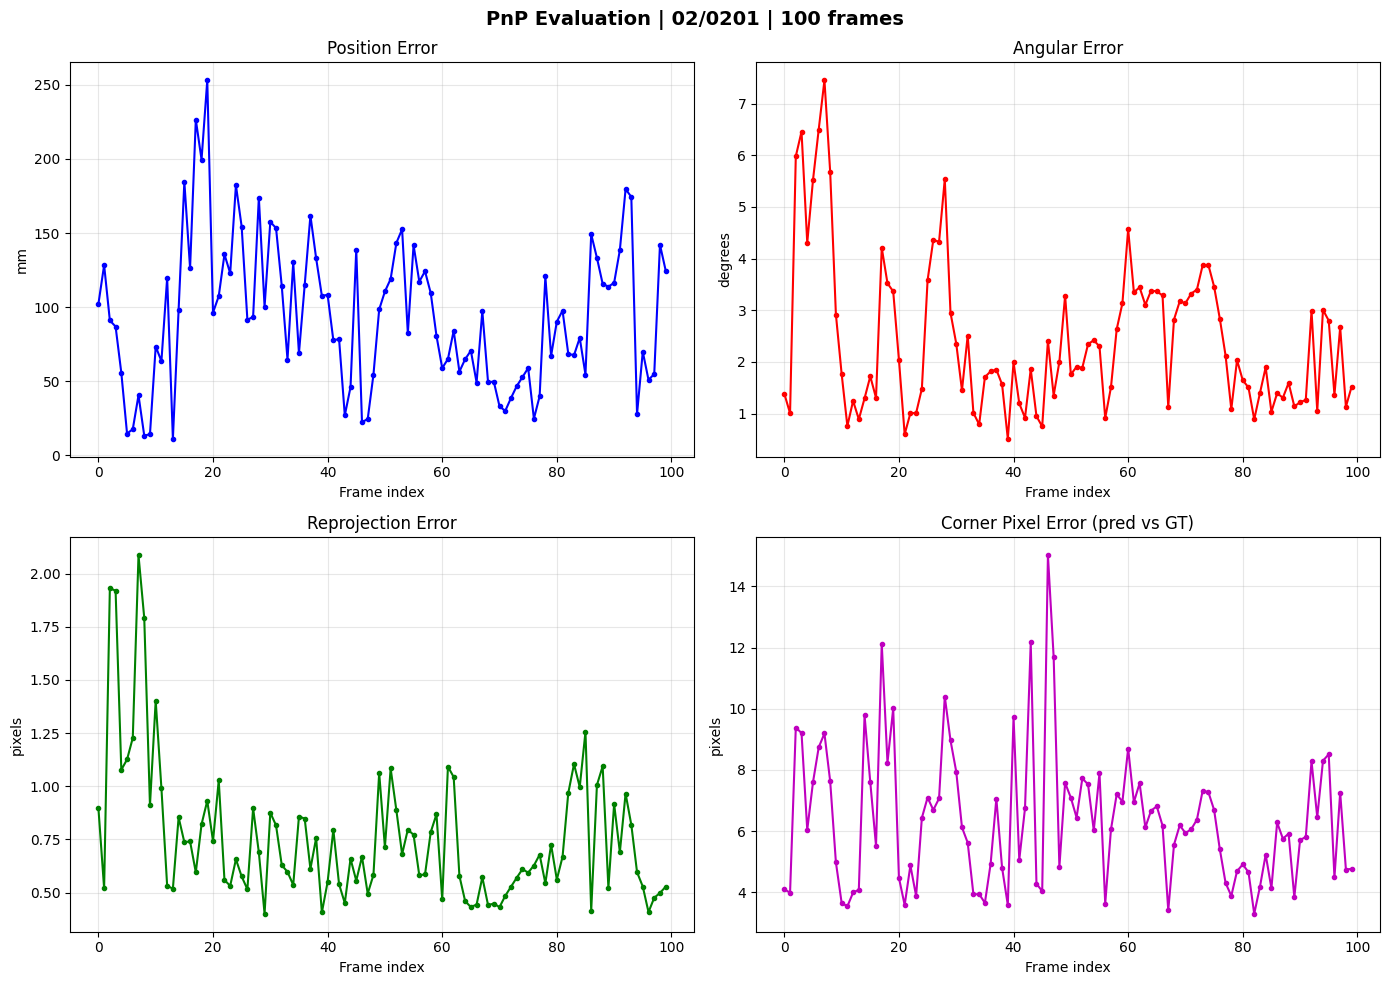

In [ ]:
#!/usr/bin/env python3
# PnP 6D POSE EVALUATION: PREDICTED 2D CORNERS → WORLD-FRAME POSE vs VICON GT
#
# PURPOSE:
#   End-to-end evaluation of the YOLOv5-6D → PnP → world-frame pose pipeline
#   on the Phantom 4 dataset. For each frame: predict 2D keypoints, solve PnP
#   to get pose in camera frame, transform to VICON world frame, and compare
#   against ground-truth UAV pose (position in mm, orientation in degrees).
#
# PIPELINE (per frame):
#   image → YOLOv5-6D → 9 keypoints (pred, pixels)
#     → solvePnP + refineLM → T_cam_mav (rotation + translation in camera frame)
#       → T_vicon_cam⁻¹ @ T_cam_mav → T_vicon_mav (pose in VICON world frame)
#         → compare vs GT uav_t / uav_q from labels/
#
# COORDINATE FRAMES & TRANSFORMS:
#   body  (MAV)  → VICON (world)   : T_vicon_mav  from GT label (uav_t, uav_q xyzw)
#   VICON (world) → camera          : VICON2CAM_T  fixed 4×4 from calibration
#   camera → body (MAV)             : T_cam_mav    from PnP (what we estimate)
#   To recover world-frame pose:    T_vicon_mav = T_vicon_cam @ T_cam_mav
#                                               = inv(VICON2CAM_T) @ T_cam_mav
#
# DATA STRUCTURES:
#   CORNERS_BODY:    (9, 3) float64 — Phantom 4 3D bbox in MAV body frame (meters)
#                    [centroid, corner1..corner8]; extents ≈ 0.34 × 0.34 × 0.23 m
#   K:               (3, 3) float64 — camera intrinsic matrix (fx≈fy≈1979, cx≈977, cy≈534)
#   DIST_COEFFS:     (5,)   float64 — [k1, k2, p1, p2, k3] (OpenCV convention)
#   VICON2CAM_T:     (4, 4) float64 — rigid transform VICON→camera (from calibration)
#
#   GT label format (labels/<seq>/<trial>/<name>.txt):
#     16 floats per line:
#       [0]    cam_time
#       [1:4]  cam_t  (VICON frame)
#       [4:8]  cam_q  (xyzw)
#       [8]    uav_time
#       [9:12] uav_t  (VICON frame)
#       [12:16] uav_q (xyzw)
#
#   YOLO label format (labels_yolo6d/<seq>/<trial>/<name>.txt):
#     class x0 y0 x1 y1 ... x8 y8 [bbox]
#     indices 1–18 = centroid + 8 corners, normalized to [0,1]
#
#   Per-frame result dict:
#     name, confidence, corner_px_err, reproj_err,
#     pos_err_m, ang_err_deg, pos_est, pos_gt, q_est, q_gt
#
# INPUT DIRECTORY LAYOUT (EXPECTED):
#   DATA_DIR/
#     JPEGImages/<SEQ>/<TRIAL>/*.jpg
#     labels/<SEQ>/<TRIAL>/*.txt          — VICON GT (cam + uav poses)
#     labels_yolo6d/<SEQ>/<TRIAL>/*.txt   — YOLO6D keypoint labels
#   WEIGHTS: phantom4/weights/best.pt
#
# DOES:
#   load_gt_label():          parse 16-float VICON GT → cam/uav pose dicts
#   gt_uav_pose_to_camera_frame(): T_cam_mav = VICON2CAM_T @ T_vicon_mav (from GT)
#   gt_corners_in_image():    project 3D corners via GT pose + full distortion model → pixels
#   predict_corners():        YOLOv5-6D inference → (9,2) pred corners in original image space
#   solve_pnp_camera_frame(): solvePnP (ITERATIVE) + refineLM on 8 corners → T_cam_mav
#                              reprojection error computed on all 9 points (incl. centroid)
#   pnp_to_world_frame():     inv(VICON2CAM_T) @ T_cam_mav → world-frame position + quaternion
#   position_error():         L2 norm of translation difference (meters)
#   angular_error_deg():      geodesic quaternion distance → degrees
#
#   Main loop:
#     - Processes up to N_IMAGES frames from one trial (SEQ/TRIAL)
#     - Per frame: predict → PnP → world transform → error metrics → visualization PNG
#     - Saves per-frame annotated overlay (GT green, pred red dashed, PnP cyan dotted)
#     - Prints summary table: position error (mm), angular error (°),
#       reprojection error (px), corner pixel error (px)
#     - Saves results.json + 4-panel time-series summary plot
#
# OUTPUT:
#   pnp_eval_<SEQ>_<TRIAL>/
#     <name>.png     — per-frame annotated overlay
#     results.json   — config, summary stats, per-frame metrics
#     summary.png    — 4 subplots: pos err, ang err, reproj err, corner err over frames
#
# DEPENDENCIES:
#   numpy, opencv, scipy, matplotlib, torch, tqdm, json
#   YOLOv5-6D-Pose repo (models.experimental, utils.{datasets,general,pose_utils,torch_utils})
#
# NOTES:
#   - PnP uses 8 box corners (centroid skipped); reprojection error uses all 9.
#   - PnP is refined with Levenberg-Marquardt (solvePnPRefineLM) after initial solve.
#   - GT image projection uses the full Brown-Conrady distortion model (k1,k2,p1,p2,k3).
#   - Quaternion convention: xyzw throughout (scipy default).
#   - Angular error: geodesic distance 2·arccos(|q₁·q₂|), handles double-cover.

import numpy as np
import cv2
import sys
import json
from pathlib import Path
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================

YOLO_REPO = str(Path.home() / "git/YOLOv5-6D-Pose")
WEIGHTS = str(Path.home() / "Desktop/YOLOv5-6D-Pose/runs/train/phantom4/weights/best.pt")
DATA_DIR = Path.home() / "Desktop/YOLOv5-6D-Pose/data/data/phantom4"

# Which sequence/trial to test
SEQ = "02"
TRIAL = "0201"
N_IMAGES = 100  # how many images to test (None = all)

DEVICE = ""  # '' = auto, 'cpu', '0' for GPU

# ============================================================================
# CONSTANTS
# ============================================================================

# Camera intrinsics (Phantom 4)
FX, FY, CX, CY = 1979.4, 1979.1, 976.8189, 533.9717
K = np.array([[FX, 0, CX],
              [0, FY, CY],
              [0,  0,  1]], dtype=np.float64)

DIST_COEFFS = np.array([-0.2306, 0.1497, -0.00089582, -0.00086321, -0.0522086113480487],
                        dtype=np.float64)

# VICON -> Camera transform (fixed, from calibration)
VICON2CAM_T = np.array([
    [0.6685859,  -0.74342,     0.01787715, -0.3814142759180792],
    [0.01558769, -0.01002444, -0.99982825,  1.604836888783723],
    [0.74347153,  0.66874974,  0.004886,    3.035574156448842],
    [0,           0,           0,            1]
], dtype=np.float64)

# Phantom 4 3D bounding box corners in MAV body frame
MIN_X, MAX_X = -0.18, 0.16
MIN_Y, MAX_Y = -0.16, 0.18
MIN_Z, MAX_Z = -0.17, 0.06

CORNERS_BODY = np.array([
    [(MIN_X + MAX_X) / 2, (MIN_Y + MAX_Y) / 2, (MIN_Z + MAX_Z) / 2],  # centroid
    [MIN_X, MIN_Y, MIN_Z],
    [MIN_X, MIN_Y, MAX_Z],
    [MIN_X, MAX_Y, MIN_Z],
    [MIN_X, MAX_Y, MAX_Z],
    [MAX_X, MIN_Y, MIN_Z],
    [MAX_X, MIN_Y, MAX_Z],
    [MAX_X, MAX_Y, MIN_Z],
    [MAX_X, MAX_Y, MAX_Z],
], dtype=np.float64)


# ============================================================================
# LABEL LOADING
# ============================================================================

def load_gt_label(label_path):
    """
    Load GT label from labels/ directory.
    Format: timestamp_cam tx ty tz rx ry rz rw timestamp_uav tx ty tz rx ry rz rw
    
    Returns dict with camera and UAV poses in VICON frame.
    """
    with open(label_path) as f:
        vals = [float(x) for x in f.readline().strip().split()]

    return {
        "cam_t": np.array(vals[1:4]),
        "cam_q_xyzw": np.array(vals[4:8]),
        "uav_t": np.array(vals[9:12]),
        "uav_q_xyzw": np.array(vals[12:16]),
    }


def load_yolo_label(label_path):
    """
    Load YOLO 6D label from labels_yolo6d/ directory.
    Format: class cx cy x1 y1 x2 y2 ... x8 y8 [bbox]
    Returns normalized 2D corners (9x2): centroid + 8 corners.
    """
    with open(label_path) as f:
        vals = [float(x) for x in f.readline().strip().split()]
    # indices 1-18: centroid + 8 corners (normalized 0-1)
    corners_norm = np.array(vals[1:19]).reshape(9, 2)
    return corners_norm


def gt_uav_pose_to_camera_frame(gt):
    """
    Compute GT pose of MAV in camera frame from VICON-frame UAV pose.
    
    Pipeline:
        corners_body -> MAV_to_VICON (uav pose) -> VICON_to_Camera (fixed T)
    
    Returns:
        R_cam_mav: 3x3 rotation (MAV -> camera frame)
        t_cam_mav: 3x1 translation (MAV origin in camera frame)
    """
    # MAV -> VICON
    r_uav = R.from_quat(gt["uav_q_xyzw"])
    R_vicon_mav = r_uav.as_matrix()
    t_vicon_mav = gt["uav_t"]

    # Build 4x4: MAV -> VICON
    T_vicon_mav = np.eye(4)
    T_vicon_mav[:3, :3] = R_vicon_mav
    T_vicon_mav[:3, 3] = t_vicon_mav

    # Full chain: MAV -> VICON -> Camera
    T_cam_mav = VICON2CAM_T @ T_vicon_mav

    R_cam_mav = T_cam_mav[:3, :3]
    t_cam_mav = T_cam_mav[:3, 3]

    return R_cam_mav, t_cam_mav


def gt_corners_in_image(gt):
    """
    Project 3D corners to image using GT pose (same math as dataset's get_projection).
    Returns 9x2 pixel coordinates.
    """
    R_cam_mav, t_cam_mav = gt_uav_pose_to_camera_frame(gt)

    # Transform corners to camera frame
    pts_cam = (R_cam_mav @ CORNERS_BODY.T + t_cam_mav.reshape(3, 1))  # 3x9

    # Normalize
    xp = pts_cam[0] / pts_cam[2]
    yp = pts_cam[1] / pts_cam[2]

    # Apply distortion
    r2 = xp * xp + yp * yp
    D = DIST_COEFFS
    x_dist = xp * (1 + D[0]*r2 + D[1]*r2**2 + D[4]*r2**3) + 2*D[2]*xp*yp + D[3]*(r2 + 2*xp**2)
    y_dist = yp * (1 + D[0]*r2 + D[1]*r2**2 + D[4]*r2**3) + D[2]*(r2 + 2*yp**2) + 2*D[3]*xp*yp

    # To pixel
    u = FX * x_dist + CX
    v = FY * y_dist + CY

    return np.column_stack([u, v])


# ============================================================================
# PREDICTION (YOLOv5-6D)
# ============================================================================

def load_model(weights, device_str):
    """Load YOLOv5-6D model."""
    import torch
    sys.path.insert(0, YOLO_REPO)
    from models.experimental import attempt_load
    from utils.torch_utils import select_device

    device = select_device(device_str)
    model = attempt_load(weights, map_location=device)
    model.eval()
    return model, device


def predict_corners(model, image_path, device, img_size=640, conf_thresh=0.01):
    """
    Run YOLOv5-6D inference on a single image.
    Returns predicted 2D corners in original image space (9x2) and confidence.
    """
    import torch
    sys.path.insert(0, YOLO_REPO)
    from utils.datasets import letterbox
    from utils.general import check_img_size, scale_coords
    from utils.pose_utils import box_filter

    img0 = cv2.imread(str(image_path))
    if img0 is None:
        return None, None, "Failed to load image"
    h0, w0 = img0.shape[:2]

    stride = int(model.stride.max())
    img_size = check_img_size(img_size, s=stride)
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))

    img_t = img[:, :, ::-1].transpose(2, 0, 1)
    img_t = np.ascontiguousarray(img_t)
    img_t = torch.from_numpy(img_t).to(device).float() / 255.0
    if img_t.ndimension() == 3:
        img_t = img_t.unsqueeze(0)

    with torch.no_grad():
        pred, _ = model(img_t)

    pred = box_filter(pred, conf_thres=conf_thresh, max_det=10)

    if pred is None or len(pred) == 0 or len(pred[0]) == 0:
        return None, None, "No detections"

    det = pred[0][0].clone().cpu()
    confidence = float(det[18])
    corners_pred = det[:18].reshape(1, 18)

    scale_coords(img_t.shape[2:], corners_pred, shape, shapes[1])
    pred_pixels = corners_pred[0].numpy().reshape(9, 2)

    return pred_pixels, confidence, None


# ============================================================================
# PnP SOLVER
# ============================================================================

def solve_pnp_camera_frame(corners_2d, use_distortion=True):
    """
    Solve PnP: given predicted 2D corners, get MAV pose in camera frame.
    
    Uses corners [1:] (skip centroid) for PnP.
    Returns rvec, tvec, R_cam_mav, reprojection_error or None on failure.
    """
    obj_pts = CORNERS_BODY[1:].astype(np.float64)  # 8x3
    img_pts = corners_2d[1:].astype(np.float64)     # 8x2

    dist = DIST_COEFFS if use_distortion else np.zeros(5)

    success, rvec, tvec = cv2.solvePnP(
        obj_pts, img_pts, K, dist, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not success:
        return None

    # Refine
    rvec, tvec = cv2.solvePnPRefineLM(obj_pts, img_pts, K, dist, rvec, tvec)

    R_cam_mav, _ = cv2.Rodrigues(rvec)

    # Reprojection error (on all 9 points including centroid)
    all_obj = CORNERS_BODY.astype(np.float64)
    all_img = corners_2d.astype(np.float64)
    proj, _ = cv2.projectPoints(all_obj, rvec, tvec, K, dist)
    proj = proj.reshape(-1, 2)
    reproj_err = np.mean(np.linalg.norm(proj - all_img, axis=1))

    return {
        "rvec": rvec,
        "tvec": tvec.flatten(),
        "R_cam_mav": R_cam_mav,
        "t_cam_mav": tvec.flatten(),
        "reprojection_error": reproj_err,
        "projected_corners": proj,
    }


def pnp_to_world_frame(pnp_result):
    """
    Transform PnP result from camera frame to VICON world frame.
    
    PnP gives us T_cam_mav (MAV in camera frame).
    We know T_cam_vicon = VICON2CAM_T.
    
    T_cam_mav = T_cam_vicon @ T_vicon_mav
    => T_vicon_mav = T_cam_vicon^{-1} @ T_cam_mav
    """
    T_cam_mav = np.eye(4)
    T_cam_mav[:3, :3] = pnp_result["R_cam_mav"]
    T_cam_mav[:3, 3] = pnp_result["t_cam_mav"]

    T_cam_vicon = VICON2CAM_T
    T_vicon_cam = np.linalg.inv(T_cam_vicon)

    T_vicon_mav = T_vicon_cam @ T_cam_mav

    pos_world = T_vicon_mav[:3, 3]
    rot_world = R.from_matrix(T_vicon_mav[:3, :3])
    q_world = rot_world.as_quat()  # xyzw

    return pos_world, q_world


# ============================================================================
# ERROR METRICS
# ============================================================================

def position_error(pos_est, pos_gt):
    return np.linalg.norm(pos_est - pos_gt)


def angular_error_deg(q_est, q_gt):
    """Angular error between two quaternions (xyzw) in degrees."""
    dot = np.clip(np.abs(np.dot(q_est, q_gt)), 0.0, 1.0)
    return np.rad2deg(2.0 * np.arccos(dot))


# ============================================================================
# VISUALIZATION
# ============================================================================

# 3D bounding box edges (indices into corners[1:], so 0-based among 8 corners)
EDGES = [
    [0, 1], [0, 2], [0, 4],
    [1, 3], [1, 5],
    [2, 3], [2, 6],
    [3, 7],
    [4, 5], [4, 6],
    [5, 7],
    [6, 7],
]


def draw_box_on_image(ax, corners_9x2, color, label, linestyle="-", linewidth=2):
    """Draw 3D bounding box edges on matplotlib axis. corners_9x2 includes centroid at [0]."""
    for i, (a, b) in enumerate(EDGES):
        ax.plot(
            [corners_9x2[a + 1, 0], corners_9x2[b + 1, 0]],
            [corners_9x2[a + 1, 1], corners_9x2[b + 1, 1]],
            color=color, linestyle=linestyle, linewidth=linewidth,
            label=label if i == 0 else "",
        )
    # Centroid
    ax.scatter(corners_9x2[0, 0], corners_9x2[0, 1], c=color, s=120, marker="*",
               edgecolors="black", linewidths=1, zorder=5)


def visualize_frame(img_bgr, pred_corners, gt_corners_img, pnp_result, frame_name,
                    pos_err_mm, ang_err_deg, confidence, save_path=None):
    """Visualize GT, prediction, and PnP reprojection on one frame."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 9))
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    # GT box (green)
    draw_box_on_image(ax, gt_corners_img, "lime", "GT", linewidth=3)

    # Predicted corners (red dashed)
    draw_box_on_image(ax, pred_corners, "red", "Prediction", linestyle="--", linewidth=2)

    # PnP reprojection (cyan dotted)
    if pnp_result is not None:
        draw_box_on_image(ax, pnp_result["projected_corners"], "cyan", "PnP reproject",
                          linestyle=":", linewidth=2)

    title = (f"{frame_name} | conf={confidence:.3f} | "
             f"pos_err={pos_err_mm:.1f}mm | ang_err={ang_err_deg:.2f}° | "
             f"reproj={pnp_result['reprojection_error']:.2f}px")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=11, loc="upper right")
    ax.axis("off")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return fig


# ============================================================================
# MAIN
# ============================================================================

def main():
    print("=" * 80)
    print("PnP EVALUATION ON PHANTOM 4 DATASET")
    print("=" * 80)

    # --- Discover images ---
    img_dir = DATA_DIR / "JPEGImages" / SEQ / TRIAL
    label_dir = DATA_DIR / "labels" / SEQ / TRIAL
    yolo_label_dir = DATA_DIR / "labels_yolo6d" / SEQ / TRIAL

    image_files = sorted(img_dir.glob("*.jpg"))
    if N_IMAGES is not None:
        image_files = image_files[:N_IMAGES]

    print(f"Sequence: {SEQ}/{TRIAL}")
    print(f"Images:   {len(image_files)}")
    print(f"Weights:  {WEIGHTS}")
    print()

    # --- Load model ---
    print("Loading model...")
    model, device = load_model(WEIGHTS, DEVICE)
    print("Model loaded.\n")

    # --- Output directory ---
    out_dir = Path(f"pnp_eval_{SEQ}_{TRIAL}")
    out_dir.mkdir(exist_ok=True)

    # --- Process frames ---
    results = []

    for img_path in tqdm(image_files, desc="Processing"):
        name = img_path.stem
        gt_label_path = label_dir / f"{name}.txt"
        yolo_label_path = yolo_label_dir / f"{name}.txt"

        # Load GT
        if not gt_label_path.exists():
            print(f"  SKIP {name}: no GT label")
            continue
        gt = load_gt_label(gt_label_path)

        # GT corners projected to image (for visualization)
        gt_corners_img = gt_corners_in_image(gt)

        # Predict
        pred_corners, confidence, err_msg = predict_corners(model, img_path, device)
        if pred_corners is None:
            print(f"  SKIP {name}: {err_msg}")
            continue

        # Corner pixel error (pred vs GT image projection)
        corner_px_err = np.mean(np.linalg.norm(pred_corners[1:] - gt_corners_img[1:], axis=1))

        # PnP
        pnp = solve_pnp_camera_frame(pred_corners, use_distortion=True)
        if pnp is None:
            print(f"  SKIP {name}: PnP failed")
            continue

        # Transform to world frame
        pos_est, q_est = pnp_to_world_frame(pnp)

        # GT in world frame
        pos_gt = gt["uav_t"]
        q_gt = gt["uav_q_xyzw"]

        # Errors
        pos_err = position_error(pos_est, pos_gt)
        ang_err = angular_error_deg(q_est, q_gt)

        results.append({
            "name": name,
            "confidence": confidence,
            "corner_px_err": corner_px_err,
            "reproj_err": pnp["reprojection_error"],
            "pos_err_m": pos_err,
            "ang_err_deg": ang_err,
            "pos_est": pos_est.tolist(),
            "pos_gt": pos_gt.tolist(),
            "q_est": q_est.tolist(),
            "q_gt": q_gt.tolist(),
        })

        # Visualize
        img_bgr = cv2.imread(str(img_path))
        visualize_frame(
            img_bgr, pred_corners, gt_corners_img, pnp, name,
            pos_err * 1000, ang_err, confidence,
            save_path=out_dir / f"{name}.png",
        )

    # ================================================================
    # SUMMARY
    # ================================================================
    if not results:
        print("\n❌ No successful results!")
        return

    pos_errs = np.array([r["pos_err_m"] for r in results])
    ang_errs = np.array([r["ang_err_deg"] for r in results])
    reproj_errs = np.array([r["reproj_err"] for r in results])
    corner_errs = np.array([r["corner_px_err"] for r in results])

    print("\n" + "=" * 80)
    print(f"RESULTS | seq={SEQ}/{TRIAL} | {len(results)} frames")
    print("=" * 80)
    print(f"{'Metric':<30} {'Mean':>12} {'Median':>12} {'Max':>12}")
    print("-" * 70)
    print(f"{'Position error [mm]':<30} {pos_errs.mean()*1000:>12.1f} {np.median(pos_errs)*1000:>12.1f} {pos_errs.max()*1000:>12.1f}")
    print(f"{'Angular error [°]':<30} {ang_errs.mean():>12.2f} {np.median(ang_errs):>12.2f} {ang_errs.max():>12.2f}")
    print(f"{'Reprojection error [px]':<30} {reproj_errs.mean():>12.2f} {np.median(reproj_errs):>12.2f} {reproj_errs.max():>12.2f}")
    print(f"{'Corner pixel error [px]':<30} {corner_errs.mean():>12.2f} {np.median(corner_errs):>12.2f} {corner_errs.max():>12.2f}")
    print("=" * 80)

    # Save results JSON
    json_path = out_dir / "results.json"
    with open(json_path, "w") as f:
        json.dump({
            "config": {"seq": SEQ, "trial": TRIAL, "n_images": N_IMAGES, "weights": WEIGHTS},
            "summary": {
                "n_frames": len(results),
                "pos_err_mm_mean": float(pos_errs.mean() * 1000),
                "pos_err_mm_median": float(np.median(pos_errs) * 1000),
                "ang_err_deg_mean": float(ang_errs.mean()),
                "ang_err_deg_median": float(np.median(ang_errs)),
                "reproj_err_px_mean": float(reproj_errs.mean()),
            },
            "frames": results,
        }, f, indent=2)
    print(f"\nSaved results to {json_path}")

    # --- Summary plots ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(pos_errs * 1000, "b.-")
    axes[0, 0].set_title("Position Error")
    axes[0, 0].set_ylabel("mm")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(ang_errs, "r.-")
    axes[0, 1].set_title("Angular Error")
    axes[0, 1].set_ylabel("degrees")
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(reproj_errs, "g.-")
    axes[1, 0].set_title("Reprojection Error")
    axes[1, 0].set_ylabel("pixels")
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(corner_errs, "m.-")
    axes[1, 1].set_title("Corner Pixel Error (pred vs GT)")
    axes[1, 1].set_ylabel("pixels")
    axes[1, 1].grid(True, alpha=0.3)

    for ax in axes.flat:
        ax.set_xlabel("Frame index")

    plt.suptitle(f"PnP Evaluation | {SEQ}/{TRIAL} | {len(results)} frames", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_dir / "summary.png", dpi=150, bbox_inches="tight")
    print(f"Saved summary plot to {out_dir / 'summary.png'}")
    plt.show()


if __name__ == "__main__":
    main()